**Name: Riley Chen**

**UB ID: 50501486**

# Project 6: Monte Carlo Simulation

## 1. Introduction

Life insurance companies need to know how long people are likely to live to set fair premiums and plan payouts. **Actuaries** use **life tables** to estimate the probability that someone of a certain age will survive to the next year. These tables give precise numbers, but real life is uncertain, people don’t all live exactly as the tables predict.

This is where **Monte Carlo simulations** come in. It will model individual lifetimes randomly based on a life table. By simulating thousands of lifetimes, I can see how survival patterns emerge, calculate average life expectancy, and estimate potential insurance payouts. Comparing these results to the life table shows how well the simulation captures real-world variability while still matching theoretical expectations. This approach helps illustrate how randomness can be incorporated into actuarial models and insurance calculations.

## 2. Import Life Table Data

To start the simulation, I first need to import the life table data. The CSV file contains ages and the corresponding probability of dying within that year `qx`. I’ll write a Python function called `ImportLifeTable(FileName)` to read this CSV and store the values in arrays for easy access.

In addition to `qx`, I will compute the probability of surviving each year, denoted `px`, using the formula:

$$ p_x = 1 - q_x $$

Here, `px` represents the probability that an individual of age $x$ survives to age $x+1$. Computing `px` is important because the Monte Carlo simulation will rely on these survival probabilities to determine whether each simulated individual lives through each year or dies, which is the core mechanism for modeling random lifetimes.


In [228]:
import numpy as np
import csv

def ImportLifeTable(FileName):
    ages = []
    qx = []
    with open(FileName, 'r') as file:
        reader = csv.reader(file)
        next(reader)
        for row in reader:
            ages.append(int(row[0]))
            qx.append(float(row[1]))
    ages = np.array(ages)
    qx = np.array(qx)
    px = 1 - qx
    return ages, qx, px

The function `ImportLifeTable` reads the CSV file containing ages and death probabilities `qx`. It stores the ages and qx values in arrays for easy access, then computes the survival probabilities `px = 1 - qx` for each age. These arrays are returned so the simulation can use them to model whether each individual survives each year.

## 3. Lifetime Simulation

We will now model a single individual’s lifetime using **Monte Carlo**. The process goes as follows, start at age 0, and for each year, generate a random number between 0 and 1. If the random number is less than the death probability `qx` for that age, the individual dies that year. Otherwise, they survive to the next year. This continues year by year until death occurs, and the function returns the age at death. This approach allows us to capture the randomness in lifetimes while still respecting the probabilities given by the life table. Each call to the function gives a **different** outcome, reflecting the variability of real-world lifespans.

In [96]:
def SimulateLifetime(qx):
    age = 0
    while age < len(qx):
        if np.random.rand() < qx[age]:
            return age
        age += 1
    return age

The function `SimulateLifetime(qx)` uses `np.random.rand()` to generate a random number between 0 and 1 for each year. This number is then compared to `qx[age]` to determine whether the individual survives that year. The process continues year by year until the person dies, and the function returns the simulated **age at death**, representing a single lifetime outcome based on the life table.

## 4. Monte Carlo Simulation Engine

Since we don't want to focus solely on one individual's lifetime (we aim to model multiple lifetimes), we will utilize the **Monte Carlo Simulation Engine** to simulate thousands of lifetimes. For each simulated individual, we will apply the survival probabilities year by year, recording the age at death. Repeating this process many times creates a distribution of lifetimes, allowing us to see overall survival patterns and calculate average life expectancy. This approach gives a more complete picture of how populations behave over time compared to a single lifetime outcome.

In [191]:
def RunSim(qx, n):
    lifetimes = []
    for _ in range(n):
        lifetimes.append(SimulateLifetime(qx))
    return np.array(lifetimes)

The Monte Carlo simulation engine runs many individual lifetime simulations using the `SimulateLifetime` function. Each time, it generates a random lifetime based on the survival probabilities in the life table. Running this for `n` individuals produces a distribution of lifetimes that can be analyzed to see overall survival patterns and calculate statistics like average life expectancy.

## 5. Survival and Expectation Calculations

Once many lifetimes have been simulated, the next step is to evaluate how the results compare to the life table. The first calculation is the **empirical survival probability**, which measures the fraction of simulated individuals who survive to each age. This produces a survival curve based entirely on simulated data.

In [175]:
def EmpiricalSurvival(lifetimes, max_age):
    survival_probs = []
    for age in range(max_age + 1):
        survived = np.sum(lifetimes >= age)
        survival_probs.append(survived / len(lifetimes))
    return np.array(survival_probs)

Next, the **expected remaining lifetime** is computed for each age. For every age in the range, all simulated individuals who are still alive at that age are identified, and the average number of years they live beyond that point is calculated. This shows the typical remaining lifespan for someone who has already reached a given age.

In [178]:
def ExpectedRemaining(lifetimes, max_age):
    remaining_life = []
    for age in range(max_age + 1):
        alive = lifetimes[lifetimes >= age]
        if len(alive) > 0:
            remaining = np.mean(alive - age)
        else:
            remaining = 0
        remaining_life.append(remaining)
    return np.array(remaining_life)

## 6. Visualization of Simulation Results

To better understand the results of the simulation, the lifetimes and survival data are visualized in several ways. The first plot is a **histogram of the simulated lifetimes**, which shows how ages at death are distributed across the 10,000 individuals. This allows the overall shape of the mortality pattern to be seen, including where most deaths occur and how wide the distribution is.

Next, an **empirical survival curve** is plotted using the simulated data. This curve shows the probability of surviving to each age based on the outcomes of the Monte Carlo process. It provides a clear picture of how survival decreases over time within the simulated population.

Finally, a plot of the **expected remaining lifetime** is included. This graph displays, for each age, the average number of years a person can expect to live given that they have already reached that age. It summarizes long-term survival patterns and shows how remaining life decreases steadily as age increases.

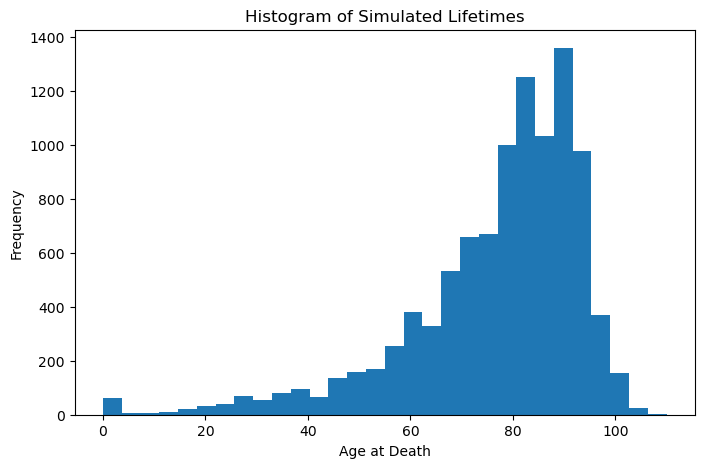

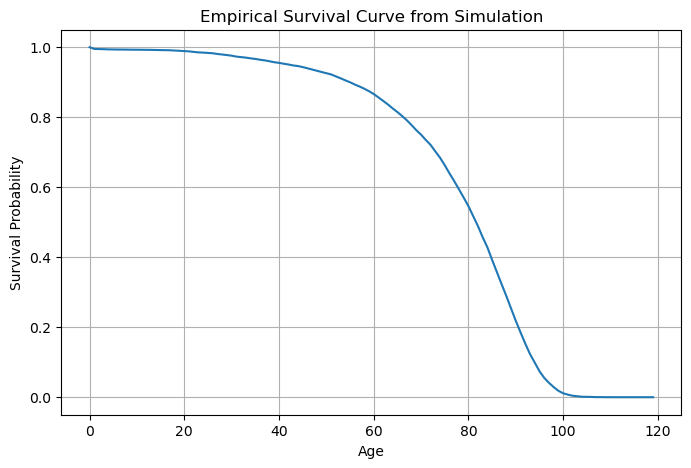

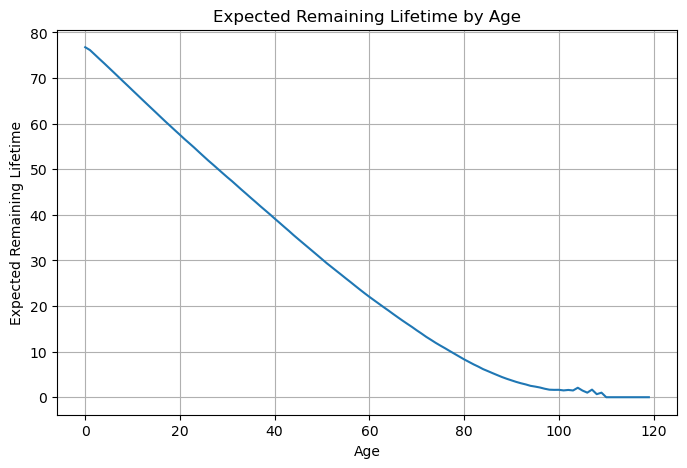

In [216]:
import matplotlib.pyplot as plt

ages, qx, px = ImportLifeTable("combined_life_table_2022.csv") 
n = 10000
lifetimes = RunSim(qx, n)

plt.figure(figsize=(8,5))
plt.hist(lifetimes, bins=30)
plt.xlabel("Age at Death")
plt.ylabel("Frequency")
plt.title("Histogram of Simulated Lifetimes")
plt.show()

max_age = len(qx) - 1

emp_surv = EmpiricalSurvival(lifetimes, max_age)

plt.figure(figsize=(8,5))
plt.plot(emp_surv)
plt.xlabel("Age")
plt.ylabel("Survival Probability")
plt.title("Empirical Survival Curve from Simulation")
plt.grid(True)
plt.show()

exp_rem = ExpectedRemaining(lifetimes, max_age)

plt.figure(figsize=(8,5))
plt.plot(exp_rem)
plt.xlabel("Age")
plt.ylabel("Expected Remaining Lifetime")
plt.title("Expected Remaining Lifetime by Age")
plt.grid(True)
plt.show()


The histogram of simulated lifetimes shows a clear concentration of deaths in the **late 70s to early 80s**, which lines up with the peak of the bars. The distribution tapers off on both sides, with fewer individuals dying very young and fewer surviving into the 90s or beyond. This shape reflects a realistic lifespan pattern based on the life table probabilities used in the simulation.

The empirical survival curve begins at 1 and decreases gradually through childhood and adulthood, then drops more noticeably as individuals reach older ages. The curve declines steadily and reaches very low survival probabilities by the early 90s, matching the lifespan pattern seen in the histogram.

The expected remaining lifetime curve starts high, around **76 years at birth**, and decreases smoothly as age increases. The slope becomes steeper at older ages, showing that remaining lifetime shrinks faster once individuals move into their later years. This plot summarizes how longevity changes across the lifespan in the simulated population.


## 7. Empirical vs Theoretical

It’s important to check whether the results actually match what the life table predicts. To do this, I compared the **empirical survival curve** from the simulated lifetimes to the **theoretical survival curve** that comes directly from the life table. The theoretical curve is computed by multiplying the survival probabilities year by year.  

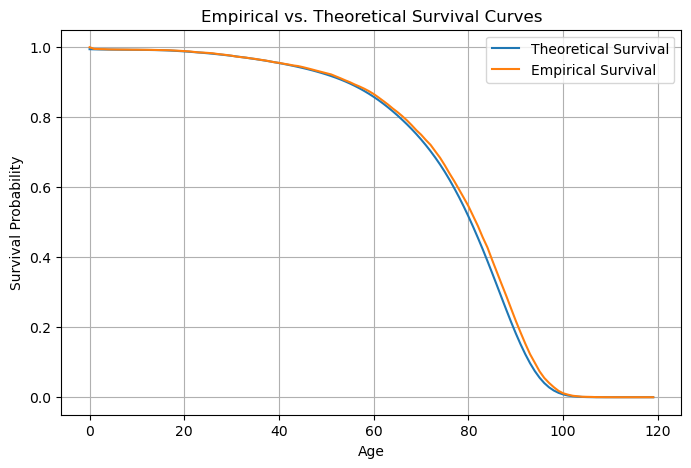

In [239]:
theo_surv = np.cumprod(px)

plt.figure(figsize=(8,5))
plt.plot(theo_surv, label="Theoretical Survival")
plt.plot(emp_surv, label="Empirical Survival")
plt.xlabel("Age")
plt.ylabel("Survival Probability")
plt.title("Empirical vs. Theoretical Survival Curves")
plt.legend()
plt.grid(True)
plt.show()

The **empirical survival curve** closely follows the **theoretical curve** throughout most of the lifespan. This shows that the simulation is correctly applying the life-table probabilities and reproducing the expected survival pattern. Small differences appear at older ages, mainly because fewer individuals survive to those ages in the simulation, which increases variability.

## 8. Conclusion 

Monte Carlo simulation based on a realistic life table provides a powerful way to see how individual randomness aggregates into population‑level patterns. The simulated lifetimes produced a distribution with most deaths occurring in the **late 70s to early 80s**, which aligns with typical human mortality and supports that the algorithm correctly reflects the `qx` probabilities. The empirical survival curve and expected remaining lifetime function both behaved as expected: survival declines gradually at younger ages and then more sharply at older ages, while remaining life starts high at birth and shrinks faster once individuals reach later life. 

One extension would be to incorporate separate life tables for **different groups** (such as males vs. females or smokers vs. non‑smokers) and compare how the simulated survival curves and life expectancies differ across subpopulations. We can also take a look toincorporate life tables from **different countries** or **regions** to show how where people live affects their lifetimes, since factors like healthcare quality, income, environment, and public health policies can significantly shift the simulated survival curves and life expectancy across populations.